# **Сравнительная геномика** | Семинар + ДЗ

##### Ссылка на репозиторий и этот ноутбук с файлами: github: https://github.com/randnull/genotec/blob/main/hw_5_dnds.ipynb

Домашнее задание 5

**Дисклеймер** \
Предполагается, что вы ознакомились с лекцией перед тем, как открыть этот ноутбук. Здесь не будет подробных объяснений теоретических основ сравнительной геномики, поэтому если они вам не знакомы, то первым делом изучите лекционный материал

**ПОЛИТИКА В ОТНОШЕНИИ ГПТ** \
Я не психопат (во всяком случае не настолько), чтобы с серьезным лицом запрещать вам использовать ллмки. Однако, если вы делаете это крайне безответственно, то будут санкции в виде снижения оценки. Например, однажды в Сколтехе студентка написала функцию определения $R^2$ в ячейке под той, в которой показано, как вызвать подсчет этой метрики в phylokrr одной строкой. Лицо мое представили

**ЕЩЕ ОДНО ПРЕДУПРЕЖДЕНИЕ! Не запускайте бездумно все ячейки подряд, как бы сильно не хотелось. Спамить шифт+энтер здесь не получится...**

Небольшой дисклеймер - в ноутбук отсуствует несколько комментариев автора, так как я перенес все локально, гпт (а точнее клод) тут убрал conda-костыли (и честно дальше он использоваться только для QA по биологии), так как работа не происходила в колабе.

In [1]:
!hyphy --version


HYPHY 2.5.85(MP) for Darwin on arm64 ARM Neon SIMD zlib (v1.3.1)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import subprocess
import os
import json
warnings.filterwarnings('ignore')

In [3]:
!hyphy --version

HYPHY 2.5.85(MP) for Darwin on arm64 ARM Neon SIMD zlib (v1.3.1)


In [4]:
!git clone https://github.com/Malaevleo/cba_comp_age_hw.git


fatal: destination path 'cba_comp_age_hw' already exists and is not an empty directory.


## Вступление

В этом ноутбуке мы сфокусируемся на отряде *Chiroptera* (Рукокрылые). Многие его представители живут удивительно долго. Например, *Myotis brandtii* (Ночница Брандта) может жить 40+ лет при весе всего в 7 грамм. Очень интересно узнать, какие генетические адаптации могут стоять за таким биологическим феноменом

Дерево из TimeTree:
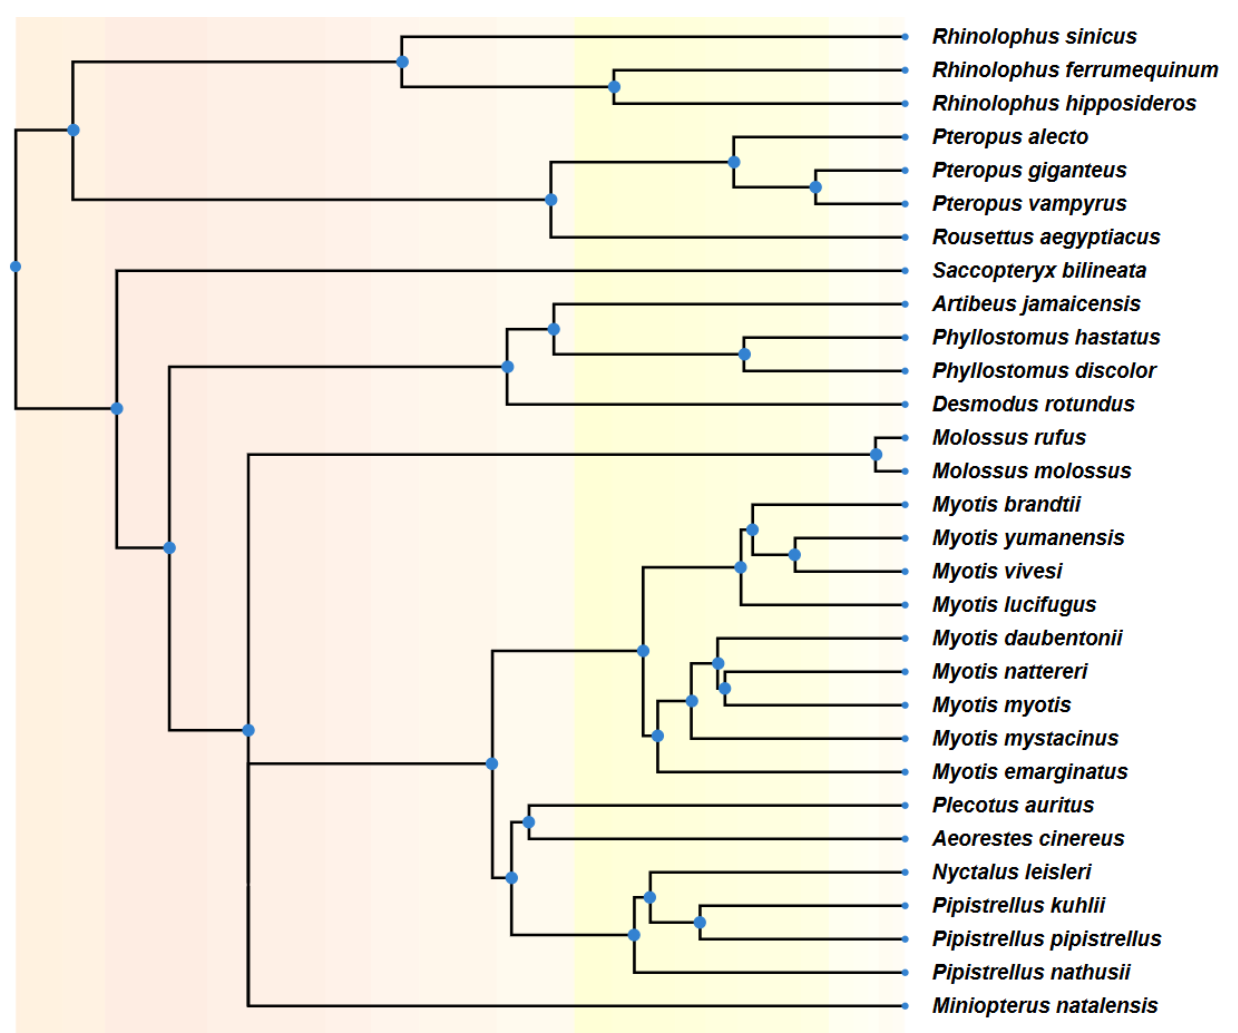

Добавим значения LQ из датабазы AnnAge и разделим летучих мышей на 3 категории в зависимости от LQ.

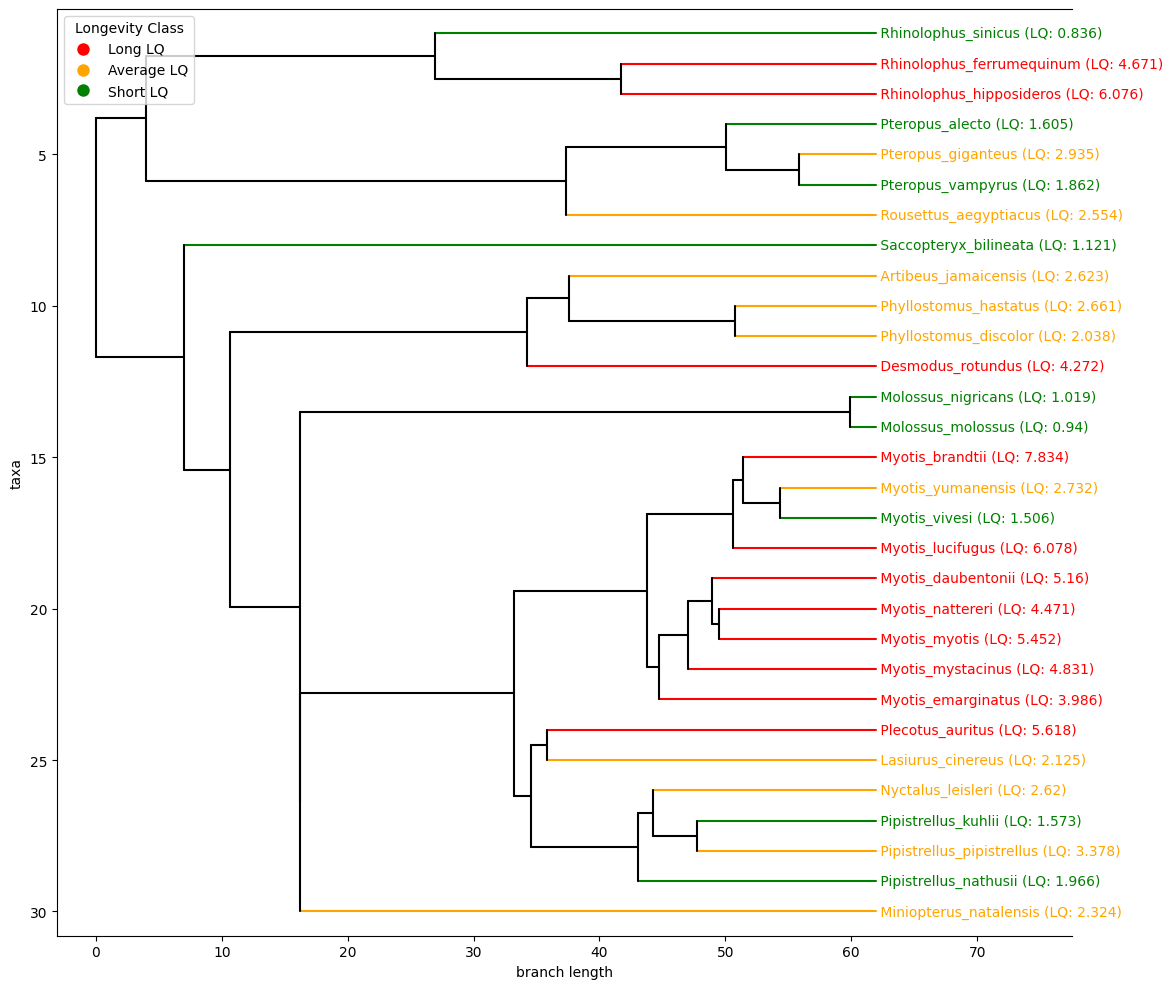

Всего у нас 30 видов, что, конечно, не так уж и много, но вполне неплохо для одной клады. Особенно интересно разнообразие по продолжительности жизни, нормализованной по массе.

Проведем анализ, взяв за основу следующий пайплайн:

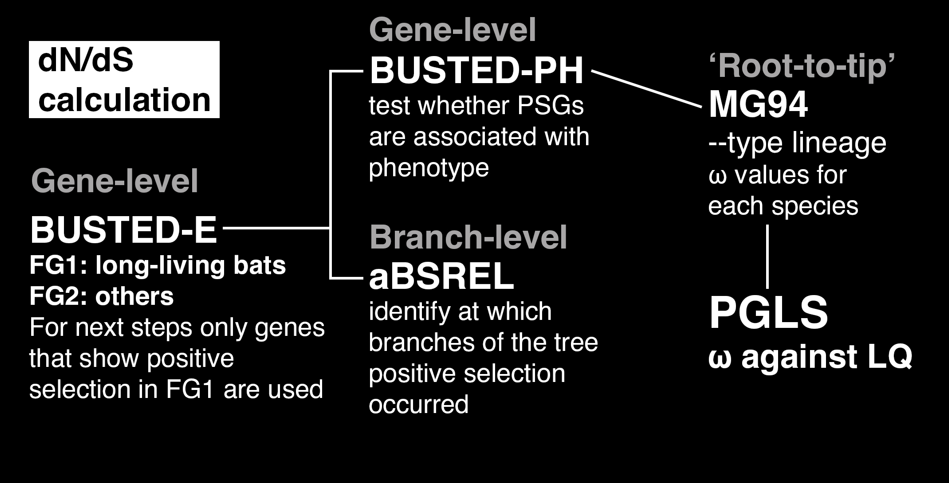

Он включает в себя почти все, что обсуждалось на лекции, а также позволяет оценить отбор на уровне индивидуальных ветвей и оценить ассоциацию dN/dS с любой количественной метрикой (в нашем случае LQ).

## Данные

Для каждого гена у нас есть и MSA, и дерево.

**MMP25:** \
mmp25_aln.fasta -> MSA \
mmp25_tree.nwk -> phylogenetic tree \
Аналогично для других генов (CLEC14A, POLG).

MMP25 - матрисомная металлпротеаза, являющаяся важным компонентом внеклеточного матрикса.

## dN/dS

### BUSTED

Создадим функцию, запускающую BUSTED-E

In [4]:
def run_busted(align, tree, branches="Foreground"):

    os.makedirs("results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"results/{gene}_{branches}_res.json"
    log_file = f"results/{gene}_{branches}_log.txt"
    # команда для баша
    cmd = [
        "hyphy", "busted", # определяет, какой тул будет использован
        "--alignment", align,
        "--tree", tree,
        "--branches", branches,
        "--error-sink", "Yes", # это включает BUSTED-E
        "--output", out_json,
        "ENV=TOLERATE_NUMERICAL_ERRORS=1"
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)
    print(f"✅ Done: {out_json}")


Наша функция `run_busted` использует 3 аргумента:

1.   `align` MSA
2.   `tree` дерево
3. `branches` какая группа ветвей тестируется на положительный отбор. Модель с 3 $\omega$ классами фитится на эти ветви



Проанализируем MMP25, используя нашу функцию:

In [5]:
run_busted("cba_comp_age_hw/mmp25_aln.fasta","cba_comp_age_hw/mmp25_tree.nwk","Foreground")


✅ Done: results/mmp25_Foreground_res.json


В среднем на прогон уходит от 5 до 40 минут в случае большого количества видов

*Можно прогнать BUSTED-E и через одну длинную команду, что для биоинформатики вообще-то классика...*

In [ ]:
#!hyphy busted --alignment cba_comp_age_hw/mmp25_aln.fasta --tree cba_comp_age_hw/mmp25_tree.nwk --branches Foreground --error-sink Yes ENV=TOLERATE_NUMERICAL_ERRORS=1 --output mmp25_res.json > mmp25_log.txt 2>&1


*ну или так:*

In [ ]:
%%bash
hyphy busted \
 --alignment cba_comp_age_hw/mmp25_aln.fasta \
  --tree cba_comp_age_hw/mmp25_tree.nwk \
  --branches Foreground \
   --error-sink Yes \
   --output mmp25_res.json > mmp25_log.txt 2>&1


`> mmp25_log.txt 2>&1` \
Используется для сохранения очень удобного лога, который BUSTED выводит в командную строку. Иногда удобно просто поглядеть на него, чтобы все понять.

Давайте посмотрим на результаты. Они сохранены в json файле и еще в txt с логом.

Можем визуализировать json:

In [6]:
def check_busted_results(path="results/mmp25_Foreground_res.json"):
  with open(path) as f:
      data = json.load(f)

  # на BackGround, там в целом нет Constrained model, так как похоже нигде не было положительного отбора
  data['fits']['Constrained model'] = data['fits'].get('Constrained model', {})
  data['fits']['Constrained model']["Log Likelihood"] = data['fits']['Constrained model'].get("Log Likelihood", 0)

  lrt = data["test results"]["LRT"]
  print(f"LRT statistic: {lrt:.4f}")
  p_value = data["test results"]["p-value"]
  print(f"P-value: {p_value:.4g}")
  logL_unconstrained = data["fits"]["Unconstrained model"]["Log Likelihood"]
  print(f"Unconstrained logL: {logL_unconstrained:.4f}")
  logL_constrained = data["fits"]["Constrained model"]["Log Likelihood"]
  print(f"Constrained logL: {logL_constrained:.4f}")

check_busted_results(path="results/mmp25_Foreground_res.json")

LRT statistic: 6.1485
P-value: 0.02311
Unconstrained logL: -7931.3714
Constrained logL: -7934.4456


Как мы видим, этот ген претерпевает положительный отбор. Для более детального анализа перейдем к следующим стадиям пайплайна.

ДЛЯ НАСТОЯЩИХ ЦЕНИТЕЛЕЙ СРАВНИТЕЛЬНОЙ ГЕНОМИКИ: \
*Результаты могут слегка разниться в зависимости от фита модели. Самый лучший способ получить абсолютно воспроизводимый результат заключается в предварительном фите обычного BUSTED, извлечения параметров и уже дальнейшего запуска BUSTED-E.*

Можно посмотреть, есть ли отбор на фоновых ветвях.

In [7]:
run_busted("cba_comp_age_hw/mmp25_aln.fasta","cba_comp_age_hw/mmp25_tree.nwk","Background")


✅ Done: results/mmp25_Background_res.json


In [8]:
check_busted_results(path="results/mmp25_Background_res.json")

LRT statistic: 0.0000
P-value: 0.5
Unconstrained logL: -7935.2256
Constrained logL: 0.0000


Вот тут видим, что положиельного отбора у Background не было

**Давайте изучим, на каких конкретно ветвях дерева мог возникнуть положительный отбор**

### aBSREL

В этом методе мы не указываем, какие ветви хотим смотреть, потому что он должен анализировать все.

In [9]:
def run_absrel(align, tree):
    os.makedirs("results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"results/{gene}_absrel_res.json"
    log_file = f"results/{gene}_absrel_log.txt"

    cmd = [
        "hyphy", "absrel",
        "--alignment", align,
        "--tree", tree,
        "--output", out_json
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)
    print(f"✅ Done: {out_json}")


In [10]:
run_absrel("cba_comp_age_hw/mmp25_aln.fasta","cba_comp_age_hw/mmp25_tree.nwk")


✅ Done: results/mmp25_absrel_res.json


Примерно 10 минут

*В одну строку*

In [ ]:
#!hyphy absrel --alignment cba_comp_age_hw/mmp25_aln.fasta --tree cba_comp_age_hw/mmp25_tree.nwk --output mmp25_absrel_res.json > mmp25_absrel_log.txt 2>&1


Изучим результаты:

In [11]:
with open("results/mmp25_absrel_res.json") as f:
    data = json.load(f)


pos_test_res = data["test results"]["positive test results"]


print(f"Positive test results: {pos_test_res:f}")


Positive test results: 2.000000


Ветви с положительном отбором нашлись. Давайте посмотрим, какие это мыши:

In [12]:
def check_absrel_results(path="results/mmp25_absrel_res.json"):
  with open(path) as f:
      data = json.load(f)


  pos_test_res = data["test results"]["positive test results"]


  print(f"Positive test results: {pos_test_res:f}")

  branches = data["branch attributes"]["0"]

  print("Branches under episodic positive selection:\n")

  for bname, attrs in branches.items():
      pval = attrs.get("Corrected P-value", 1)
      if pval < 0.05:
          LRT = attrs.get("LRT", None)
          rate_dist = attrs.get("Rate Distributions", [])
          omega, prop = None, None
          if len(rate_dist) > 1:  # 2+ classes → second one is usually ω>1
              omega, prop = rate_dist[-1]
          elif rate_dist:         # only one class (impossible situation basically)
              omega, prop = rate_dist[0]

          print(f"{bname:25s}  p={pval:.2e}  LRT={LRT:.2f}  ω={omega:.2f}  prop={prop:.2%}")

check_absrel_results(path="results/mmp25_absrel_res.json")

Positive test results: 2.000000
Branches under episodic positive selection:

mbXP_014392669_1           p=0.00e+00  LRT=78.80  ω=244.01  prop=4.08%
mlXP_006090523_1           p=9.87e-03  LRT=15.05  ω=2111.47  prop=0.27%


*Myotis brandtii* и *Myotis lucifugus* демонстируют положительный отбор. Это одни из самых долгоживущих летучих мышей в природе, поэтому это весьма закономерно.

## MG94 root-to-tip dN/dS calculation

MG94 с опцией "lineage" используется для расчета dN/dS от корня до вершины (листа) дерева. Корень здесь - общий предок всех рукокрылых. \
Увы, запуск root-to-tip расчета требует неких танцев с бубном, поскольку для этого нужно загружать дополнительный набор скриптов hyphy-analyses и надеяться, что патчи на сам hyphy ничего не сломали.


In [16]:
!git clone --depth 1 https://github.com/veg/hyphy-analyses.git
!hyphy hyphy-analyses/FitMG94/FitMG94.bf --help #sanity check


fatal: destination path 'hyphy-analyses' already exists and is not an empty directory.

Available analysis command line options
---------------------------------------
Use --option VALUE syntax to invoke
If a [reqired] option is not provided on the command line, the analysis will prompt for its value
[conditionally required] options may or not be required based on the values of other options

rooted
	Accept rooted trees
	default value: No

type
	Model type: 
        - global (single dN/dS for all branches) 
        - local (separate dN/dS) 
        - partitioned (separate dN/dS for user-defined groups)
        - lineage (separate dN/dS for each tip's lineage)
	default value: terms.global [computed at run time]
	applies to: Model Type

code
	Which genetic code should be used
	default value: Universal

alignment [required]
	An in-frame codon alignment in one of the formats supported by HyPhy

tree [conditionally required]
	A phylogenetic tree
	applies to: Please select a tree file for th

Если показывает гайд на MG94 -> все хорошо.

In [13]:
def run_mg94(align, tree):

    os.makedirs("results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"results/{gene}_mg94_res.json"
    log_file = f"results/{gene}_mg94_log.txt"

    cmd = [
        "hyphy", "hyphy-analyses/FitMG94/FitMG94.bf",
        "--alignment", align,
        "--tree", tree,
        "--type", "lineage",
        "--output", out_json,
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)
    print(f"✅ Done: {out_json}")


In [14]:
run_mg94("cba_comp_age_hw/mmp25_aln.fasta","cba_comp_age_hw/mmp25_tree.nwk")


✅ Done: results/mmp25_mg94_res.json


Примерно 10 мин

*В одну строку:*

In [ ]:
# !hyphy hyphy-analyses/FitMG94/FitMG94.bf --alignment cba_comp_age_hw/itih4_al.fa --tree cba_comp_age_hw/itih4_tree.nwk --output itih4_mg94_res.json > itih4_mg94_log.txt 2>&1


Создадим csv файл, который потом будем использовать для PGLS

In [15]:
d=json.load(open("results/mmp25_mg94_res.json"))["branch attributes"]["0"]
pd.DataFrame([{"node":k,"lineage_dNdS":v["Lineage dN/dS"]}for k,v in d.items()if"Lineage dN/dS"in v]).to_csv("mmp25_dnds.csv",index=False)


In [16]:
df = pd.read_csv("mmp25_dnds.csv")
df.head()

,node,lineage_dNdS
0,ajXP_037010567_1,0.158106
1,drXP_024409158_2,0.182369
2,lcg18142_t1,0.194412
3,mag18797_t1,0.222185
4,mbXP_014392669_1,0.262773


Добавим в датафрейм названия видов и LQ, потому что это потребуется для PGLS

In [17]:
REF = {
    'aj': {'Species': 'Artibeus_jamaicensis',      'LQ': 2.6},
    'dr': {'Species': 'Desmodus_rotundus',         'LQ': 4.3},
    'lc': {'Species': 'Lasiurus_cinereus',         'LQ': 2.1},
    'ma': {'Species': 'Myotis_nattereri',          'LQ': 4.5},
    'mb': {'Species': 'Myotis_brandtii',           'LQ': 7.8},
    'md': {'Species': 'Myotis_daubentonii',        'LQ': 5.2},
    'me': {'Species': 'Myotis_emarginatus',        'LQ': 4.0},
    'mi': {'Species': 'Molossus_nigricans',        'LQ': 1.0},
    'ml': {'Species': 'Myotis_lucifugus',          'LQ': 6.0},
    'mm': {'Species': 'Myotis_myotis',             'LQ': 5.5},
    'mn': {'Species': 'Miniopterus_natalensis',    'LQ': 2.3},
    'mo': {'Species': 'Molossus_molossus',         'LQ': 0.9},
    'ms': {'Species': 'Myotis_mystacinus',         'LQ': 4.8},
    'mv': {'Species': 'Myotis_vivesi',             'LQ': 1.5},
    'my': {'Species': 'Myotis_yumanensis',         'LQ': 2.7},
    'nl': {'Species': 'Nyctalus_leisleri',         'LQ': 2.6},
    'pa': {'Species': 'Pteropus_alecto',           'LQ': 1.6},
    'pd': {'Species': 'Phyllostomus_discolor',     'LQ': 2.0},
    'pg': {'Species': 'Pteropus_giganteus',        'LQ': 2.9},
    'ph': {'Species': 'Phyllostomus_hastatus',     'LQ': 2.7},
    'pk': {'Species': 'Pipistrellus_kuhlii',       'LQ': 1.6},
    'pn': {'Species': 'Pipistrellus_nathusii',     'LQ': 2.0},
    'pp': {'Species': 'Pipistrellus_pipistrellus', 'LQ': 3.4},
    'pu': {'Species': 'Plecotus_auritus',          'LQ': 5.6},
    'pv': {'Species': 'Pteropus_vampyrus',         'LQ': 1.9},
    'ra': {'Species': 'Rousettus_aegyptiacus',     'LQ': 2.6},
    'rf': {'Species': 'Rhinolophus_ferrumequinum', 'LQ': 4.7},
    'rh': {'Species': 'Rhinolophus_hipposideros',  'LQ': 6.1},
    'rs': {'Species': 'Rhinolophus_sinicus',       'LQ': 0.8},
    'sb': {'Species': 'Saccopteryx_bilineata',     'LQ': 1.1},
}


In [18]:
code = df["node"].str[:2].str.lower()
df["Species"] = code.map(lambda c: REF.get(c, {}).get("Species"))
df["LQ"] = code.map(lambda c: REF.get(c, {}).get("LQ"))

df.to_csv("mmp25_dnds_LQ.csv", index=False)
print(df.head())


               node  lineage_dNdS               Species   LQ
0  ajXP_037010567_1      0.158106  Artibeus_jamaicensis  2.6
1  drXP_024409158_2      0.182369     Desmodus_rotundus  4.3
2       lcg18142_t1      0.194412     Lasiurus_cinereus  2.1
3       mag18797_t1      0.222185      Myotis_nattereri  4.5
4  mbXP_014392669_1      0.262773       Myotis_brandtii  7.8


Давайте посмотрим, отличаются ли мыши из рода *Myotis* от остальных

group
Myotis    0.228731
Other     0.177397
Name: lineage_dNdS, dtype: float64


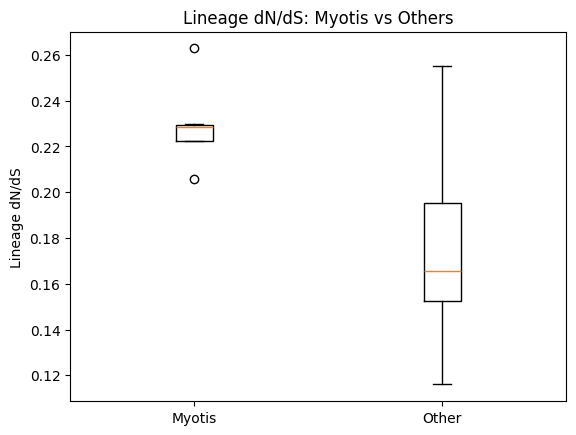

In [19]:
myotis_dict = {"mb", "ml", "md", "mm", "me", "ma", "my"}
df["code"] = df["node"].str[:2].str.lower()
df["group"] = df["code"].isin(myotis_dict).map({True: "Myotis", False: "Other"})

print(df.groupby("group")["lineage_dNdS"].mean())

plt.figure()
plt.boxplot(
    [df.loc[df["group"]=="Myotis","lineage_dNdS"],
     df.loc[df["group"]=="Other","lineage_dNdS"]],
    labels=["Myotis","Other"],
    showmeans=False
)
plt.ylabel("Lineage dN/dS")
plt.title("Lineage dN/dS: Myotis vs Others")
plt.show()

## PGLS

Вот тут сменить ядро нужно

**Обязательно убедитесь, что csv-файлы с результатами dN/dS уже сохранены** — переключение kernel'а сбрасывает все переменные в памяти.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from Bio import Phylo
from phylokrr.dataio import read_data
from phylokrr.utils import weight_data
from phylokrr.kernels import KRR
from phylokrr.utils import PGLS
from phylokrr.utils import k_fold_cv_random

In [3]:
df = pd.read_csv("mmp25_dnds_LQ.csv")
df.head()

,node,lineage_dNdS,Species,LQ
0,ajXP_037010567_1,0.158106,Artibeus_jamaicensis,2.6
1,drXP_024409158_2,0.182369,Desmodus_rotundus,4.3
2,lcg18142_t1,0.194412,Lasiurus_cinereus,2.1
3,mag18797_t1,0.222185,Myotis_nattereri,4.5
4,mbXP_014392669_1,0.262773,Myotis_brandtii,7.8


Для PGLS в phylokrr нам нужен отдельный датафрейм с независимыми переменными и таргетом, список видов и дерево. Но есть нюанс: внутренние ноды (промежуточные) не должны быть подписаны вообще никак. Почему так сделано? Потому что автор библиотеки - сверхчеловек по Ницше


In [4]:
df_modified = df.drop(["node", "Species"], axis=1)
df_modified.to_csv('test_data_mmp25.csv', index=False, header=False)
df_modified.head()

,lineage_dNdS,LQ
0,0.158106,2.6
1,0.182369,4.3
2,0.194412,2.1
3,0.222185,4.5
4,0.262773,7.8


In [5]:
species_names = df['Species']
species_names.to_csv('species_mmp25.txt', index= False, header=None)
species_names.head()

0    Artibeus_jamaicensis
1       Desmodus_rotundus
2       Lasiurus_cinereus
3        Myotis_nattereri
4         Myotis_brandtii
Name: Species, dtype: object

In [6]:
!git clone https://github.com/Malaevleo/cba_comp_age_hw.git


fatal: destination path 'cba_comp_age_hw' already exists and is not an empty directory.


In [6]:
tree_file = "cba_comp_age_hw/pgls_tree.txt"


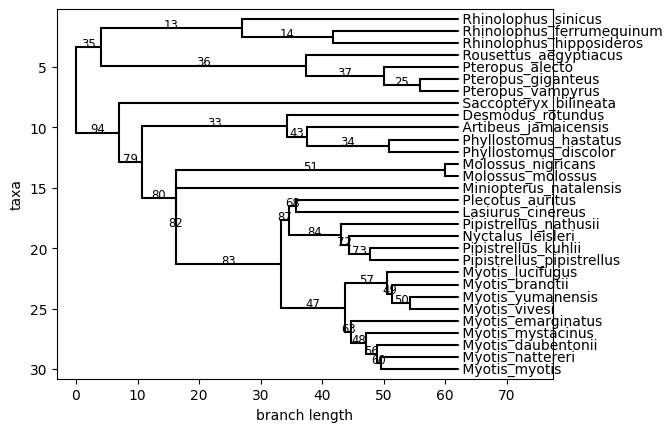

In [7]:
tree = Phylo.read(tree_file, "newick")
tree.ladderize()
Phylo.draw(tree)

Люблю ASCII арт, давайте посмотрим на наше дерево вот так:

In [8]:
Phylo.draw_ascii(tree)

                       ___________________________ Rhinolophus_sinicus
     _________________|
    |                 |           ________________ Rhinolophus_ferrumequinum
    |                 |__________|
  __|                            |________________ Rhinolophus_hipposideros
 |  |
 |  |                          ___________________ Rousettus_aegyptiacus
 |  |_________________________|
 |                            |          _________ Pteropus_alecto
 |                            |_________|
 |                                      |     ____ Pteropus_giganteus
_|                                      |____|
 |                                           |____ Pteropus_vampyrus
 |
 |     ___________________________________________ Saccopteryx_bilineata
 |    |
 |    |                      _____________________ Desmodus_rotundus
 |    |   __________________|
 |____|  |                  |  ___________________ Artibeus_jamaicensis
      |  |                  |_|
      |  |              

phylokrr может "взвешивать" данные. Это необходимо для использования нелинейного ядра. В нашем случае можно обойтись и без этого.


X shape:  (30, 1)
numeric columns:  [0]
categorical columns:  []
30 names from data, 30 from tree, 30 intersect


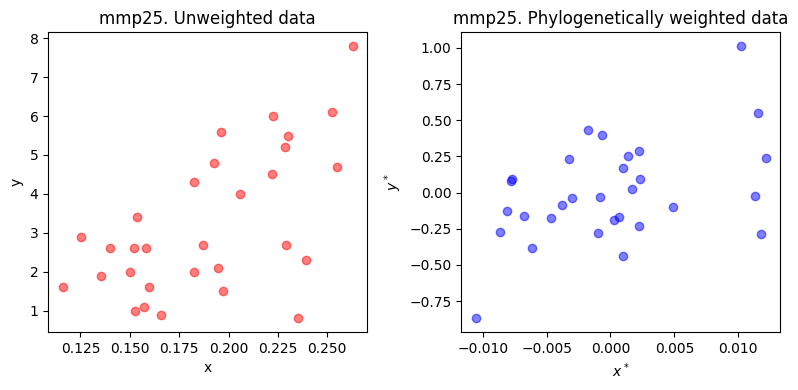

In [9]:
data_file = "test_data_mmp25.csv"


data_file_spps = "species_mmp25.txt"

X_uw_uc, y_uw_uc, vcv = read_data(tree_file, data_file, data_file_spps,
                                  y_col = 1, # таргет
                                  delimiter = ',', verbose = True)

X_w, y_w = weight_data(X_uw_uc, y_uw_uc, vcv, use_sd = False)


np.random.seed(12038)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(X_uw_uc, y_uw_uc, color = 'red', alpha=0.5, )
axs[0].set_title('mmp25. Unweighted data')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[1].scatter(X_w, y_w, color = 'blue', alpha=0.5, )
axs[1].set_title('mmp25. Phylogenetically weighted data')
axs[1].set_xlabel('$x^*$')
axs[1].set_ylabel('$y^*$')
plt.tight_layout()

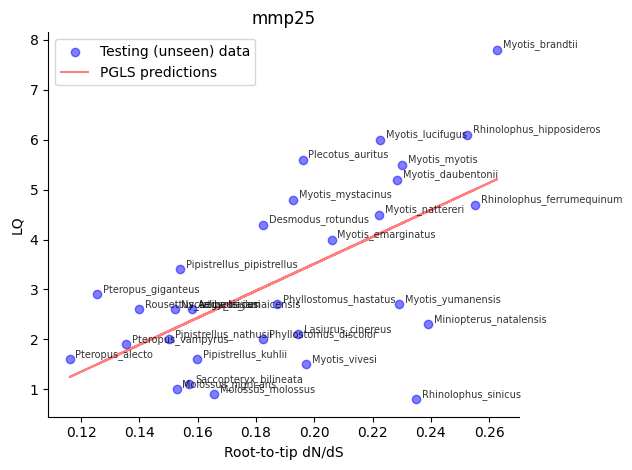

In [10]:

#X_train = X_w
#y_train = y_w
with open(data_file_spps) as f:
    species = [line.strip() for line in f]

X_train = X_uw_uc
y_train = y_uw_uc

# PGLS
pgls = PGLS(fit_intercept=True)
pgls.fit(X_train, y_train)
y_pred_pgls = pgls.predict(X_train)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(X_train, y_train , color = 'blue' , alpha=0.5, label = 'Testing (unseen) data')
plt.plot(X_train, y_pred_pgls, color = 'red', alpha=0.5, label = 'PGLS predictions')
dx = 0.002   #оффсет чтоб не было оверлепа
dy = 0.05
for i, sp in enumerate(species):
    plt.text(X_train[i] + dx, y_train[i] + dy, sp, fontsize=7, alpha=0.8)
plt.xlabel('Root-to-tip dN/dS')
plt.ylabel('LQ')
plt.title('mmp25')
plt.legend()
plt.tight_layout()

In [12]:
r2_pgls = pgls.score(X_train, y_train, metric='r2')
rmse = pgls.score(X_train, y_train, metric ='rmse')
print('mmp25')
print(f"R2 for PGLS: {r2_pgls}")
print(f"RMSE for PGLS: {rmse}")

mmp25
R2 for PGLS: 0.37111665323887977
RMSE for PGLS: 1.428897004258927


Для одного гена очень интересный результат!\

## Домашнее задание

### **Задание 1**
Проведите аналогичный анализ с генами CLEC14A и POLG. Объясните полученные результаты. Что могло пойти не так в случае с POLG?

*Всегда соблюдайте порядок видов для корректной работы PGLS*

Для каждого гена просто прораним все тоже самое

# CLEC14A

In [21]:
run_busted("cba_comp_age_hw/CLEC14A_aln.fasta","cba_comp_age_hw/CLEC14A_tree.nwk","Foreground")

✅ Done: results/CLEC14A_Foreground_res.json


In [22]:
run_busted("cba_comp_age_hw/CLEC14A_aln.fasta","cba_comp_age_hw/CLEC14A_tree.nwk","Background")

✅ Done: results/CLEC14A_Background_res.json


In [23]:
check_busted_results(path="results/CLEC14A_Foreground_res.json")

LRT statistic: 6.7090
P-value: 0.01746
Unconstrained logL: -4799.2779
Constrained logL: -4802.6324


In [24]:
check_busted_results(path="results/CLEC14A_Background_res.json")

LRT statistic: 0.2001
P-value: 0.4524
Unconstrained logL: -4807.7701
Constrained logL: -4807.8702


In [25]:
run_absrel("cba_comp_age_hw/CLEC14A_aln.fasta","cba_comp_age_hw/CLEC14A_tree.nwk")

✅ Done: results/CLEC14A_absrel_res.json


In [26]:
check_absrel_results("results/CLEC14A_absrel_res.json")

Positive test results: 1.000000
Branches under episodic positive selection:

mlXP_006085874_2           p=0.00e+00  LRT=76.47  ω=344.02  prop=5.63%


Получаем 1 ветвь, где найден положительный отбор

In [27]:
run_mg94("cba_comp_age_hw/CLEC14A_aln.fasta","cba_comp_age_hw/CLEC14A_tree.nwk")

✅ Done: results/CLEC14A_mg94_res.json


In [29]:
d=json.load(open("results/CLEC14A_mg94_res.json"))["branch attributes"]["0"]
pd.DataFrame([{"node":k,"lineage_dNdS":v["Lineage dN/dS"]}for k,v in d.items()if"Lineage dN/dS"in v]).to_csv("CLEC14A_dnds.csv",index=False)
df = pd.read_csv("CLEC14A_dnds.csv")
df.head()

,node,lineage_dNdS
0,ajXP_037021646_2,0.643480
1,drXP_024407147_2,0.632009
2,lcg2410_t1,0.429493
3,mag2668_t1,0.515755
4,mbXP_005876657_1,0.615190


In [30]:
code = df["node"].str[:2].str.lower()
df["Species"] = code.map(lambda c: REF.get(c, {}).get("Species"))
df["LQ"] = code.map(lambda c: REF.get(c, {}).get("LQ"))

df.to_csv("CLEC14A_dnds_LQ.csv", index=False)
df.head()

,node,lineage_dNdS,Species,LQ
0,ajXP_037021646_2,0.643480,Artibeus_jamaicensis,2.6
1,drXP_024407147_2,0.632009,Desmodus_rotundus,4.3
2,lcg2410_t1,0.429493,Lasiurus_cinereus,2.1
3,mag2668_t1,0.515755,Myotis_nattereri,4.5
4,mbXP_005876657_1,0.615190,Myotis_brandtii,7.8


group
Myotis    0.527855
Other     0.474985
Name: lineage_dNdS, dtype: float64


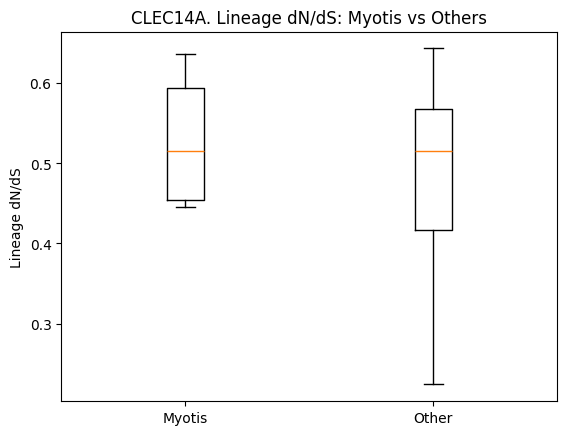

In [31]:
myotis_dict = {"mb", "ml", "md", "mm", "me", "ma", "my"}
df["code"] = df["node"].str[:2].str.lower()
df["group"] = df["code"].isin(myotis_dict).map({True: "Myotis", False: "Other"})

print(df.groupby("group")["lineage_dNdS"].mean())

plt.figure()
plt.boxplot(
    [df.loc[df["group"]=="Myotis","lineage_dNdS"],
     df.loc[df["group"]=="Other","lineage_dNdS"]],
    labels=["Myotis","Other"],
    showmeans=False
)
plt.ylabel("Lineage dN/dS")
plt.title("CLEC14A. Lineage dN/dS: Myotis vs Others")
plt.show()

Тут уже деления сильно хуже заметно, однако еще есть

# грузим ядро

In [13]:
df = pd.read_csv("CLEC14A_dnds_LQ.csv")
df.head()

,node,lineage_dNdS,Species,LQ
0,ajXP_037021646_2,0.643480,Artibeus_jamaicensis,2.6
1,drXP_024407147_2,0.632009,Desmodus_rotundus,4.3
2,lcg2410_t1,0.429493,Lasiurus_cinereus,2.1
3,mag2668_t1,0.515755,Myotis_nattereri,4.5
4,mbXP_005876657_1,0.615190,Myotis_brandtii,7.8


In [14]:
df_modified = df.drop(["node", "Species"], axis=1)
df_modified.to_csv('test_data_CLEC14A.csv', index=False, header=False)
df_modified.head()

,lineage_dNdS,LQ
0,0.643480,2.6
1,0.632009,4.3
2,0.429493,2.1
3,0.515755,4.5
4,0.615190,7.8


In [15]:
species_names = df['Species']
species_names.to_csv('species_CLEC14A.txt', index= False, header=None)
species_names.head()

0    Artibeus_jamaicensis
1       Desmodus_rotundus
2       Lasiurus_cinereus
3        Myotis_nattereri
4         Myotis_brandtii
Name: Species, dtype: object

X shape:  (30, 1)
numeric columns:  [0]
categorical columns:  []
30 names from data, 30 from tree, 30 intersect


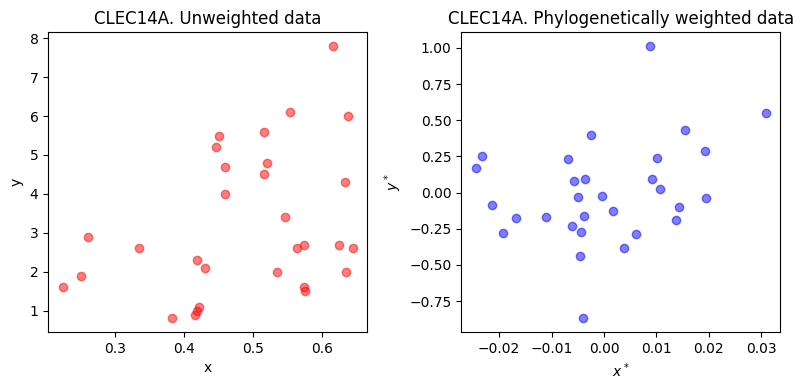

In [16]:
data_file = "test_data_CLEC14A.csv"


data_file_spps = "species_CLEC14A.txt"

X_uw_uc, y_uw_uc, vcv = read_data(tree_file, data_file, data_file_spps,
                                  y_col = 1, # таргет
                                  delimiter = ',', verbose = True)

X_w, y_w = weight_data(X_uw_uc, y_uw_uc, vcv, use_sd = False)


np.random.seed(12038)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(X_uw_uc, y_uw_uc, color = 'red', alpha=0.5, )
axs[0].set_title('CLEC14A. Unweighted data')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[1].scatter(X_w, y_w, color = 'blue', alpha=0.5, )
axs[1].set_title('CLEC14A. Phylogenetically weighted data')
axs[1].set_xlabel('$x^*$')
axs[1].set_ylabel('$y^*$')
plt.tight_layout()

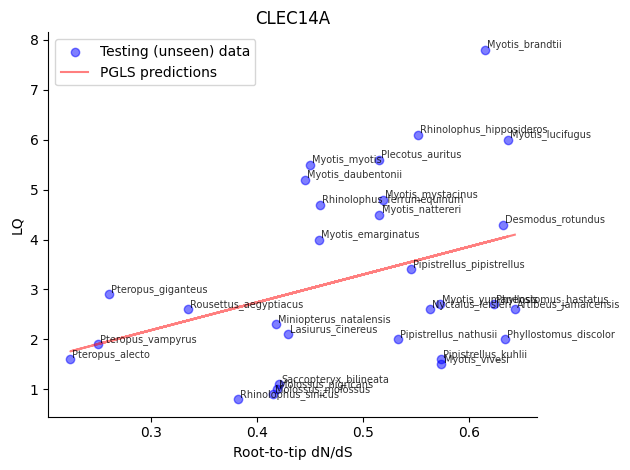

In [17]:
with open(data_file_spps) as f:
    species = [line.strip() for line in f]

X_train = X_uw_uc
y_train = y_uw_uc

# PGLS
pgls = PGLS(fit_intercept=True)
pgls.fit(X_train, y_train)
y_pred_pgls = pgls.predict(X_train)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(X_train, y_train , color = 'blue' , alpha=0.5, label = 'Testing (unseen) data')
plt.plot(X_train, y_pred_pgls, color = 'red', alpha=0.5, label = 'PGLS predictions')
dx = 0.002   #оффсет чтоб не было оверлепа
dy = 0.05
for i, sp in enumerate(species):
    plt.text(X_train[i] + dx, y_train[i] + dy, sp, fontsize=7, alpha=0.8)
plt.xlabel('Root-to-tip dN/dS')
plt.ylabel('LQ')
plt.title('CLEC14A')
plt.legend()
plt.tight_layout()

In [19]:
r2_pgls = pgls.score(X_train, y_train, metric='r2')
rmse = pgls.score(X_train, y_train, metric ='rmse')
print('CLEC14A')
print(f"R2 for PGLS: {r2_pgls}")
print(f"RMSE for PGLS: {rmse}")

CLEC14A
R2 for PGLS: 0.12826879766462762
RMSE for PGLS: 1.6823144454312091


Результаты похуже, чем для mmp25.

Однако метрики все еще дают право говорить, что ген корректно рассмотрен

# POLG

опять повторяем все тоже самое

In [32]:
run_busted("cba_comp_age_hw/POLG_aln.fasta","cba_comp_age_hw/POLG_tree.nwk","Foreground")

✅ Done: results/POLG_Foreground_res.json


In [33]:
run_busted("cba_comp_age_hw/POLG_aln.fasta","cba_comp_age_hw/POLG_tree.nwk","Background")

✅ Done: results/POLG_Background_res.json


In [34]:
check_busted_results(path="results/POLG_Foreground_res.json")

LRT statistic: 6.5116
P-value: 0.01927
Unconstrained logL: -10933.1632
Constrained logL: -10936.4190


In [35]:
check_busted_results(path="results/POLG_Background_res.json")

LRT statistic: 0.0000
P-value: 0.5
Unconstrained logL: -10953.6592
Constrained logL: 0.0000


In [36]:
run_absrel("cba_comp_age_hw/POLG_aln.fasta","cba_comp_age_hw/POLG_tree.nwk")

✅ Done: results/POLG_absrel_res.json


In [37]:
check_absrel_results("results/POLG_absrel_res.json")

Positive test results: 1.000000
Branches under episodic positive selection:

mbXP_014389040_1           p=0.00e+00  LRT=224.70  ω=5636.49  prop=8.29%


In [38]:
run_mg94("cba_comp_age_hw/POLG_aln.fasta","cba_comp_age_hw/POLG_tree.nwk")

✅ Done: results/POLG_mg94_res.json


In [39]:
d=json.load(open("results/POLG_mg94_res.json"))["branch attributes"]["0"]
pd.DataFrame([{"node":k,"lineage_dNdS":v["Lineage dN/dS"]}for k,v in d.items()if"Lineage dN/dS"in v]).to_csv("POLG_dnds.csv",index=False)
df = pd.read_csv("POLG_dnds.csv")
df.head()

,node,lineage_dNdS
0,ajXP_053514825_1,0.099949
1,drXP_045052469_2,0.104323
2,lcg45741_t1,0.084292
3,mag56686_t1,0.079257
4,mbXP_014389040_1,0.174060


In [40]:
code = df["node"].str[:2].str.lower()
df["Species"] = code.map(lambda c: REF.get(c, {}).get("Species"))
df["LQ"] = code.map(lambda c: REF.get(c, {}).get("LQ"))

df.to_csv("POLG_dnds_LQ.csv", index=False)
df.head()

,node,lineage_dNdS,Species,LQ
0,ajXP_053514825_1,0.099949,Artibeus_jamaicensis,2.6
1,drXP_045052469_2,0.104323,Desmodus_rotundus,4.3
2,lcg45741_t1,0.084292,Lasiurus_cinereus,2.1
3,mag56686_t1,0.079257,Myotis_nattereri,4.5
4,mbXP_014389040_1,0.174060,Myotis_brandtii,7.8


group
Myotis    0.09364
Other     0.09322
Name: lineage_dNdS, dtype: float64


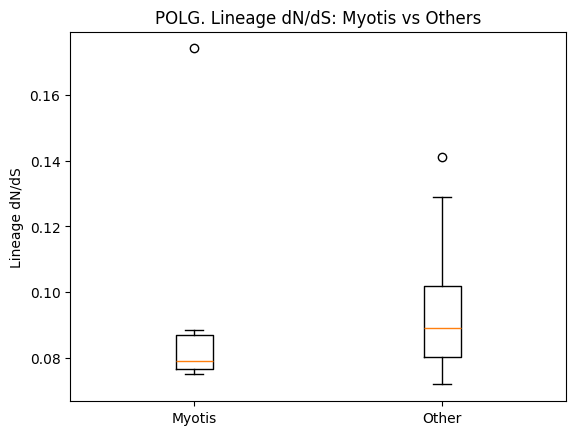

In [41]:
myotis_dict = {"mb", "ml", "md", "mm", "me", "ma", "my"}
df["code"] = df["node"].str[:2].str.lower()
df["group"] = df["code"].isin(myotis_dict).map({True: "Myotis", False: "Other"})

print(df.groupby("group")["lineage_dNdS"].mean())

plt.figure()
plt.boxplot(
    [df.loc[df["group"]=="Myotis","lineage_dNdS"],
     df.loc[df["group"]=="Other","lineage_dNdS"]],
    labels=["Myotis","Other"],
    showmeans=False
)
plt.ylabel("Lineage dN/dS")
plt.title("POLG. Lineage dN/dS: Myotis vs Others")
plt.show()

Вот тут разница опять слабо видна

# переключаем ядро на pgsl

In [20]:
df = pd.read_csv("POLG_dnds_LQ.csv")
df.head()

,node,lineage_dNdS,Species,LQ
0,ajXP_053514825_1,0.099949,Artibeus_jamaicensis,2.6
1,drXP_045052469_2,0.104323,Desmodus_rotundus,4.3
2,lcg45741_t1,0.084292,Lasiurus_cinereus,2.1
3,mag56686_t1,0.079257,Myotis_nattereri,4.5
4,mbXP_014389040_1,0.174060,Myotis_brandtii,7.8


In [21]:
df_modified = df.drop(["node", "Species"], axis=1)
df_modified.to_csv('test_data_POLG.csv', index=False, header=False)
df_modified.head()

,lineage_dNdS,LQ
0,0.099949,2.6
1,0.104323,4.3
2,0.084292,2.1
3,0.079257,4.5
4,0.174060,7.8


In [22]:
species_names = df['Species']
species_names.to_csv('species_POLG.txt', index= False, header=None)
species_names.head()

0    Artibeus_jamaicensis
1       Desmodus_rotundus
2       Lasiurus_cinereus
3        Myotis_nattereri
4         Myotis_brandtii
Name: Species, dtype: object

X shape:  (30, 1)
numeric columns:  [0]
categorical columns:  []
30 names from data, 30 from tree, 30 intersect


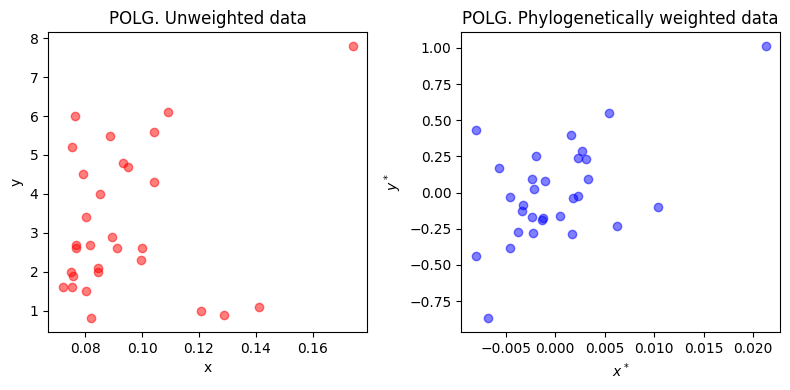

In [23]:
data_file = "test_data_POLG.csv"


data_file_spps = "species_POLG.txt"

X_uw_uc, y_uw_uc, vcv = read_data(tree_file, data_file, data_file_spps,
                                  y_col = 1, # таргет
                                  delimiter = ',', verbose = True)

X_w, y_w = weight_data(X_uw_uc, y_uw_uc, vcv, use_sd = False)


np.random.seed(12038)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(X_uw_uc, y_uw_uc, color = 'red', alpha=0.5, )
axs[0].set_title('POLG. Unweighted data')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[1].scatter(X_w, y_w, color = 'blue', alpha=0.5, )
axs[1].set_title('POLG. Phylogenetically weighted data')
axs[1].set_xlabel('$x^*$')
axs[1].set_ylabel('$y^*$')
plt.tight_layout()

Видим, что много кто имеет dn/ds очень низкий (то есть отбор по всему ген "сильно" очищающий), поэтому ген не должен дать хороший результат на метриках в модеои

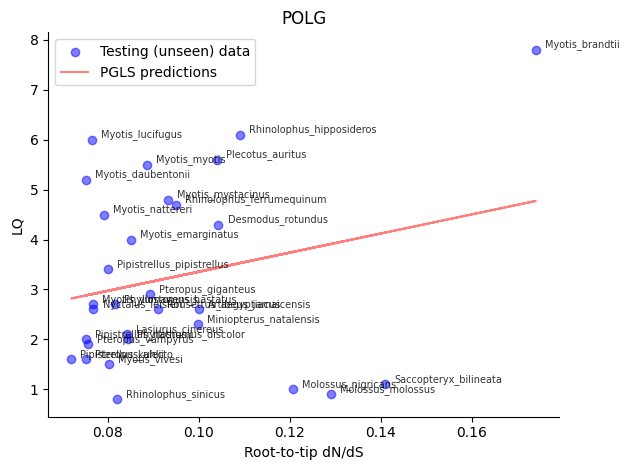

In [24]:
with open(data_file_spps) as f:
    species = [line.strip() for line in f]

X_train = X_uw_uc
y_train = y_uw_uc

# PGLS
pgls = PGLS(fit_intercept=True)
pgls.fit(X_train, y_train)
y_pred_pgls = pgls.predict(X_train)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(X_train, y_train , color = 'blue' , alpha=0.5, label = 'Testing (unseen) data')
plt.plot(X_train, y_pred_pgls, color = 'red', alpha=0.5, label = 'PGLS predictions')
dx = 0.002   #оффсет чтоб не было оверлепа
dy = 0.05
for i, sp in enumerate(species):
    plt.text(X_train[i] + dx, y_train[i] + dy, sp, fontsize=7, alpha=0.8)
plt.xlabel('Root-to-tip dN/dS')
plt.ylabel('LQ')
plt.title('POLG')
plt.legend()
plt.tight_layout()

In [25]:
r2_pgls = pgls.score(X_train, y_train, metric='r2')
rmse = pgls.score(X_train, y_train, metric ='rmse')
print('POLG')
print(f"R2 for PGLS: {r2_pgls}")
print(f"RMSE for PGLS: {rmse}")

POLG
R2 for PGLS: 0.0566354033757277
RMSE for PGLS: 1.7500709880053624


Видим, что дисперсия почти не объяснена и худшая ошибка

по графику все виды очень близки друг к другу, так как значения у всех низкое

Этот ген почти не несет информации о долгожительности

### **Задание 2**
Постройте multivariate PGLS модель на основе $\omega$ значений, получившихся для всех 3 генов. \
\
**Важно:** Если вам совсем не нравится phylokrr, то можете сделать это задание в R через caper.

К счастью, у нас вышли csv одинаковые по формату и сортировке, поэтому мы их просто смерджим

In [56]:
csv_CLEC14A = pd.read_csv("test_data_CLEC14A.csv", header=None)
csv_MMP25 = pd.read_csv("test_data_mmp25.csv", header=None)
csv_POLG = pd.read_csv("test_data_POLG.csv", header=None)

csv_CLEC14A.columns = ["dnds_clec14a", "lq"]
csv_MMP25.columns = ["dnds_mmp25", "lq"]
csv_POLG.columns = ["dnds_polg", "lq"]

pd_all = pd.merge(csv_CLEC14A.drop(columns=["lq"]), csv_MMP25.drop(columns=["lq"]), left_index=True, right_index=True)
pd_all = pd.merge(pd_all, csv_POLG, left_index=True, right_index=True)

pd_all.to_csv("pd_all.csv", index=False, header=False)
pd_all

,dnds_clec14a,dnds_mmp25,dnds_polg,lq
0,0.643480,0.158106,0.099949,2.6
1,0.632009,0.182369,0.104323,4.3
2,0.429493,0.194412,0.084292,2.1
3,0.515755,0.222185,0.079257,4.5
4,0.615190,0.262773,0.174060,7.8
5,0.445684,0.228510,0.075190,5.2
6,0.458569,0.205907,0.085080,4.0
7,0.418971,0.152751,0.120768,1.0
8,0.636711,0.222699,0.076467,6.0
9,0.450419,0.229982,0.088681,5.5


X shape:  (30, 3)
numeric columns:  [0, 1, 2]
categorical columns:  []
30 names from data, 30 from tree, 30 intersect


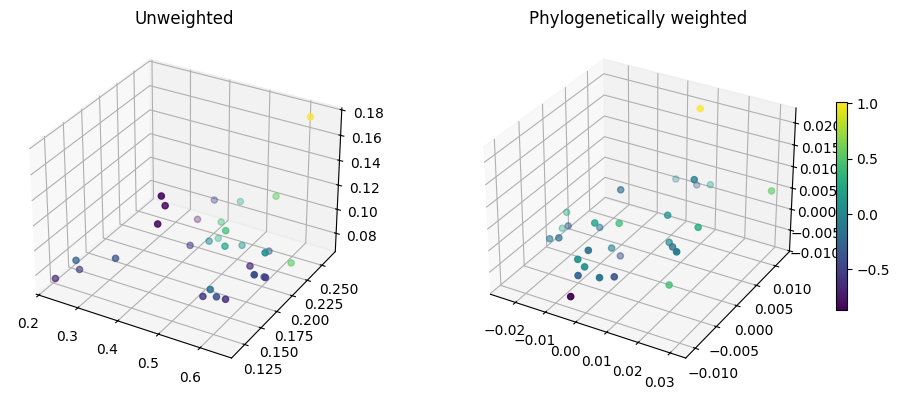

In [ ]:
data_file = "pd_all.csv"

data_file_spps = "species_CLEC14A.txt"

X_uw_uc, y_uw_uc, vcv = read_data(tree_file, data_file, data_file_spps,
                                  y_col = -1, # таргет
                                  delimiter = ',', verbose = True)

X_w, y_w = weight_data(X_uw_uc, y_uw_uc, vcv, use_sd = False)


np.random.seed(12038)

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_uw_uc[:,0], X_uw_uc[:,1], X_uw_uc[:,2], c=y_uw_uc, cmap='viridis')
ax1.set_title('Unweighted')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc = ax2.scatter(X_w[:,0], X_w[:,1], X_w[:,2], c=y_w, cmap='viridis')
ax2.set_title('Phylogenetically weighted')

fig.colorbar(sc, ax=ax2, shrink=0.6)
plt.tight_layout()
plt.show()

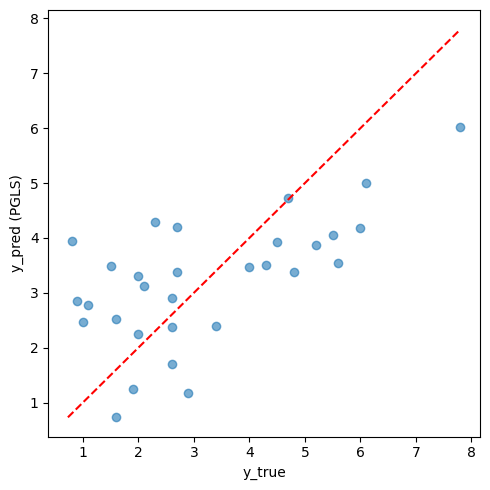

In [96]:
with open(data_file_spps) as f:
    species = [line.strip() for line in f]

X_train = X_uw_uc
y_train = y_uw_uc

plt.figure(figsize=(5, 5))
plt.scatter(y_train, y_pred_pgls, alpha=0.6)
lims = [min(y_train.min(), y_pred_pgls.min()),
        max(y_train.max(), y_pred_pgls.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('y_true'); plt.ylabel('y_pred (PGLS)')
plt.tight_layout(); plt.show()

In [97]:
r2_pgls = pgls.score(X_train, y_train, metric='r2')
rmse = pgls.score(X_train, y_train, metric ='rmse')
print('All')
print(f"R2 for PGLS: {r2_pgls}")
print(f"RMSE for PGLS: {rmse}")

All
R2 for PGLS: 0.40324496932117593
RMSE for PGLS: 1.3919188711360926


Видно, что результаты оказались лучшими, из всех трех по отдельности регрессий

для сравнения вот результаты mmp25 (лучший рез), чтобы не скролить вверх

```
mmp25
R2 for PGLS: 0.37111665323887977
RMSE for PGLS: 1.428897004258927
```

Но видно, что не так и сильно есть отличия - +0.04 в RMSE, а объясненная дисперсия +0.3

### **Задание 3**
Напишите функцию, запускающую тул MEME, анализирующий сайты под действием положительного отбора. Проанализируйте все гены им и объясните полученные результаты.

вызывем meme из hyphy

In [4]:
def run_meme(align, tree):
    os.makedirs("results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"results/{gene}_meme_res.json"
    log_file = f"results/{gene}_meme_log.txt"

    cmd = [
        "hyphy", "meme",
        "--alignment", align,
        "--tree", tree,
        "--branches", "Foreground",
        "--output", out_json
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)
    print(f"✅ Done: {out_json}")

In [8]:
run_meme("cba_comp_age_hw/mmp25_aln.fasta", "cba_comp_age_hw/mmp25_tree.nwk")

✅ Done: results/mmp25_meme_res.json


In [9]:
run_meme("cba_comp_age_hw/CLEC14A_aln.fasta", "cba_comp_age_hw/CLEC14A_tree.nwk")

✅ Done: results/CLEC14A_meme_res.json


In [10]:
run_meme("cba_comp_age_hw/POLG_aln.fasta", "cba_comp_age_hw/POLG_tree.nwk")

✅ Done: results/POLG_meme_res.json


Возьмем порог p-value 0.05, чтобы посмотреть, где реально был положительный отбор

In [13]:
d = json.load(open("results/mmp25_meme_res.json"))
cols = [c[0] for c in d["MLE"]["headers"]]
df = pd.DataFrame(d["MLE"]["content"]["0"], columns=cols)
df = df[df["p-value"] < 0.05]
df

,&alpha;,&beta;<sup>1</sup>,p<sup>1</sup>,&beta;<sup>+</sup>,p<sup>+</sup>,LRT,p-value,# branches under selection,Total branch length,MEME LogL,FEL LogL,FEL &alpha;,FEL &beta;
372,25.866430,1.331602e+01,0.555525,100000.000000,0.444475,9.604149,0.003594,1,0,-70.487076,-65.871466,0.009896,36.747883
384,13.657234,0.000000e+00,0.181579,1167.945783,0.818421,4.902476,0.039647,1,0,-25.246990,-23.102670,0.117148,16.202095
406,0.000334,2.615075e-04,0.655029,6599.671799,0.344971,8.988430,0.004912,1,0,-16.174311,-11.684171,0.011219,12.427884
407,0.000002,8.670860e-07,0.388513,67.558104,0.611487,5.537217,0.028593,2,0,-35.947151,-35.660658,0.750892,0.000003


In [14]:
d = json.load(open("results/CLEC14A_meme_res.json"))
cols = [c[0] for c in d["MLE"]["headers"]]
df = pd.DataFrame(d["MLE"]["content"]["0"], columns=cols)
df = df[df["p-value"] < 0.05]
df

,&alpha;,&beta;<sup>1</sup>,p<sup>1</sup>,&beta;<sup>+</sup>,p<sup>+</sup>,LRT,p-value,# branches under selection,Total branch length,MEME LogL,FEL LogL,FEL &alpha;,FEL &beta;
70,0.020910,1.167197e-02,0.460623,190.037793,0.539377,7.661130,0.009648,3,0,-33.464428,-32.446829,0.361462,0.018372
151,0.000123,3.066278e-08,0.007512,30.492816,0.992488,7.330645,0.011419,3,0,-19.333468,-19.341004,1.000000,0.000123
236,0.000030,1.415979e-05,0.648284,1296.152796,0.351716,14.517277,0.000300,1,0,-14.776945,-12.110498,0.069499,0.000032
240,2.168055,1.161448e+00,0.294912,165.311394,0.705088,13.483028,0.000505,1,0,-35.964214,-35.696239,0.764927,2.155233
243,0.000056,3.195207e-05,0.283477,55.447889,0.716523,11.485433,0.001386,3,0,-26.131977,-26.009192,0.884454,0.000044
247,7.663912,0.000000e+00,0.510617,186.120632,0.489383,6.598596,0.016595,1,0,-39.251343,-38.131679,0.326390,8.224561


In [15]:
d = json.load(open("results/POLG_meme_res.json"))
cols = [c[0] for c in d["MLE"]["headers"]]
df = pd.DataFrame(d["MLE"]["content"]["0"], columns=cols)
df = df[df["p-value"] < 0.05]
df

,&alpha;,&beta;<sup>1</sup>,p<sup>1</sup>,&beta;<sup>+</sup>,p<sup>+</sup>,LRT,p-value,# branches under selection,Total branch length,MEME LogL,FEL LogL,FEL &alpha;,FEL &beta;
3,0.003402,0.001678,0.611907,84.855761,0.388093,6.216474,0.020180,1,0,-11.391429,-10.366331,0.358761,0.005066
101,15.288033,0.000000,0.554048,280.838029,0.445952,5.069622,0.036373,2,0,-43.028196,-40.509529,0.080567,16.919943
178,0.000011,0.000007,0.642826,41978.630922,0.357174,5.884070,0.023928,1,0,-42.173066,-39.817655,0.094854,0.367029
292,0.073421,0.036639,0.690707,253.480524,0.309293,7.085785,0.012938,1,0,-13.651624,-11.422766,0.107651,0.087675
295,0.000020,0.000010,0.435865,78.854191,0.564135,6.021437,0.022301,1,0,-9.960261,-9.207867,0.471237,0.000026
524,24.860137,0.000000,0.675021,37355.892223,0.324979,5.609028,0.027557,1,0,-38.741555,-35.619008,0.044045,27.818541


Видно, что для разных генов нашлось от 4 до 6 сайтов, в которых был обнаружен положительный отбор (вероятно)

В целом это логично, так как мы нашли около 1-2 ветви для каждого гена через aBSREL. 

Там мы это просто усредняли, а сейчас глянули более подробно на все

(Отдельно благодарю этот метод за прогресс-бар)